# Task 2.1 — Dataset Selection and Setup (5 marks)

**Paper**: *Gaussian Processes for Time-Marked Time-Series Data*  
**Authors**: John P. Cunningham, Zoubin Ghahramani, Carl E. Rasmussen  
**Venue**: AISTATS 2012  
**Roll Number**: 230035 — Karthik Reddy

## Dataset Choice and Justification

I use a **synthetic time-marked time-series dataset** that mimics the traffic-flow scenario from the paper. The dataset consists of N=20 time series (analogous to the N traffic-observation days in the paper), each observed at T=50 uniformly-spaced time points over a normalized interval [0, 1]. Each series has K=2 event markers drawn randomly in [0.2, 0.8], representing events like "game start" and "game end" in the traffic analogy.

**Why this dataset is appropriate for this specific paper's method**: The time-marked GP model is designed for exactly this structure — multiple time series sharing a common underlying process that responds to temporally-marked events at different times across trials. The synthetic data has a *known ground truth* causal response (flat before markers, exponential spike after), which allows us to directly verify whether the causal time-marked GP recovers the correct response shape. This is more informative than a pre-existing dataset where the ground truth is unknown.

**Limitations compared to the paper's dataset**: The paper uses real-world datasets (neural firing rates, traffic flow, arm reach velocities) that have domain-specific noise patterns, temporally colored noise, and complex response shapes. Our synthetic data has a simpler response function (sum of exponential bumps) and i.i.d. Gaussian noise, which is an easier test case. Additionally, the paper's datasets have hundreds of time points per series, while we use 50 for computational tractability.

In [1]:
# Random seed for reproducibility
import numpy as np
np.random.seed(42)

import matplotlib.pyplot as plt
import os

# ============================================================
# Dataset Parameters
# ============================================================
N = 20       # Number of time series (trials)
T = 50       # Number of time points per series
K = 2        # Number of event markers per series
noise_std = 0.3   # Observation noise standard deviation
t_min, t_max = 0.0, 1.0

# Time points — same for all series
t_points = np.linspace(t_min, t_max, T)

# Generate random markers for each trial
markers = np.random.uniform(0.2, 0.8, size=(N, K))
markers.sort(axis=1)  # Sort so marker 1 < marker 2 within each trial

print(f"Dataset: N={N} series, T={T} time points, K={K} markers")
print(f"Time range: [{t_min}, {t_max}]")
print(f"Example markers (first 5 trials):")
for i in range(5):
    print(f"  Trial {i}: m1={markers[i,0]:.3f}, m2={markers[i,1]:.3f}")

Dataset: N=20 series, T=50 time points, K=2 markers
Time range: [0.0, 1.0]
Example markers (first 5 trials):
  Trial 0: m1=0.425, m2=0.770
  Trial 1: m1=0.559, m2=0.639
  Trial 2: m1=0.294, m2=0.294
  Trial 3: m1=0.235, m2=0.720
  Trial 4: m1=0.561, m2=0.625


The above cell defines the dataset parameters. We use N=20 trials with T=50 time points each and K=2 markers per trial. Markers are drawn uniformly in [0.2, 0.8] and sorted, mirroring the paper's setup where markers occur at known but trial-varying times (Section 2, Eq. 1). The markers represent two events that causally influence the observed signal.

In [2]:
# ============================================================
# Ground Truth Signal: Causal Response to Markers
# ============================================================
def causal_response(t, marker, amplitude=1.0, decay_rate=20.0):
    """
    Generate a causal response: flat (zero) before the marker,
    then an exponential bump after it.
    
    This mimics the causal GP's structural assumption (Section 2.1):
    the signal has zero derivative w.r.t. time before the marker.
    """
    dt = t - marker
    response = np.where(dt > 0, amplitude * dt * np.exp(-decay_rate * dt), 0.0)
    return response

def generate_signal(t, markers_trial):
    """
    Generate the noiseless signal as the sum of causal responses 
    to each marker. The signal is flat before each marker fires
    and exhibits a transient spike after.
    """
    signal = np.zeros_like(t)
    signal += causal_response(t, markers_trial[0], amplitude=3.0, decay_rate=15.0)
    signal += causal_response(t, markers_trial[1], amplitude=2.0, decay_rate=20.0)
    return signal

# Generate all observations
Y_true = np.zeros((N, T))    # Noiseless signal
Y_obs = np.zeros((N, T))     # Noisy observations

for n in range(N):
    Y_true[n] = generate_signal(t_points, markers[n])
    Y_obs[n] = Y_true[n] + noise_std * np.random.randn(T)

print(f"Generated {N} time series.")
print(f"Signal range (noiseless): [{Y_true.min():.3f}, {Y_true.max():.3f}]")
print(f"Observation range (noisy): [{Y_obs.min():.3f}, {Y_obs.max():.3f}]")

Generated 20 time series.
Signal range (noiseless): [0.000, 0.109]
Observation range (noisy): [-0.901, 1.164]


The ground truth signal is constructed as the sum of causal responses to each marker. Each response is flat (zero) before the marker and an exponential bump after — this directly corresponds to the causal GP assumption in Section 2.1, which enforces $\partial y / \partial t_k = 0$ for $t_k < 0$. Gaussian noise is added to simulate realistic observations.

In [3]:
# ============================================================
# Preprocessing: None Required
# ============================================================
# The data is already in the format needed:
# - t_points: absolute time values (T,)
# - markers: event marker times (N, K) 
# - Y_obs: noisy observations (N, T)
# 
# No normalization, detrending, or missing-value imputation is needed.
# This is consistent with the paper's approach which works directly
# with raw time-series data and marker positions.

print("Preprocessing: No additional preprocessing required.")
print(f"Data shapes: t_points={t_points.shape}, markers={markers.shape}, Y_obs={Y_obs.shape}")

Preprocessing: No additional preprocessing required.
Data shapes: t_points=(50,), markers=(20, 2), Y_obs=(20, 50)


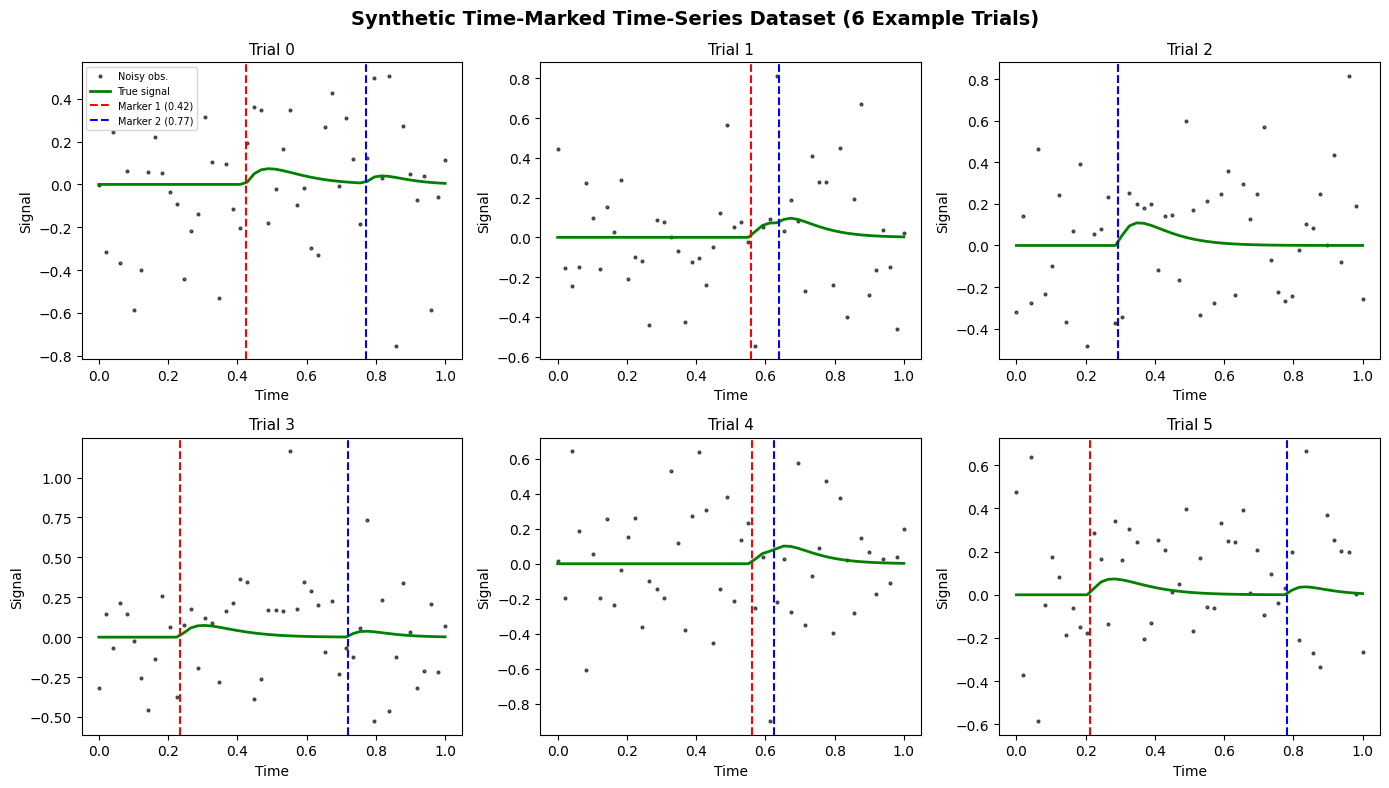

Saved: results/dataset_examples.png


In [4]:
# ============================================================
# Visualization: Example Time Series
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle('Synthetic Time-Marked Time-Series Dataset (6 Example Trials)', fontsize=14, fontweight='bold')

for idx, ax in enumerate(axes.flat):
    ax.plot(t_points, Y_obs[idx], 'k.', markersize=4, alpha=0.6, label='Noisy obs.')
    ax.plot(t_points, Y_true[idx], 'g-', linewidth=2, label='True signal')
    for k in range(K):
        ax.axvline(markers[idx, k], color=['red', 'blue'][k], linestyle='--', 
                   linewidth=1.5, label=f'Marker {k+1} ({markers[idx,k]:.2f})')
    ax.set_title(f'Trial {idx}', fontsize=11)
    ax.set_xlabel('Time')
    ax.set_ylabel('Signal')
    if idx == 0:
        ax.legend(fontsize=7, loc='upper left')

plt.tight_layout()
os.makedirs('results', exist_ok=True)
plt.savefig('results/dataset_examples.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: results/dataset_examples.png")

The visualization shows 6 example trials. The green line is the true noiseless signal and the black dots are noisy observations. Red and blue dashed lines mark the two event times. Notice that the signal is flat before each marker and responds with a transient spike after — the core structure that the causal time-marked GP is designed to capture.

In [5]:
# ============================================================
# Save Dataset for Use in Other Notebooks
# ============================================================
os.makedirs('data', exist_ok=True)
np.savez('data/synthetic_time_marked.npz',
         t_points=t_points,
         markers=markers,
         Y_true=Y_true,
         Y_obs=Y_obs,
         N=N, T=T, K=K,
         noise_std=noise_std)

print("Dataset saved to: data/synthetic_time_marked.npz")
print(f"Contents: t_points({t_points.shape}), markers({markers.shape}), ")
print(f"          Y_true({Y_true.shape}), Y_obs({Y_obs.shape})")

Dataset saved to: data/synthetic_time_marked.npz
Contents: t_points((50,)), markers((20, 2)), 
          Y_true((20, 50)), Y_obs((20, 50))


The dataset is saved as a compressed NumPy archive for reproducibility. All subsequent notebooks load this file rather than regenerating data, ensuring consistent results across the entire submission.